# Tugas Data Wrangling: Preprocessing Lengkap pada Dataset Kotor ICU Survival Prediction

**Sumber data:** Kaggle - ML League 2026 Task 2: ICU Survival Prediction (`train.csv`)
**Target:** `survived_icu` (1 = selamat, 0 = tidak selamat) - klasifikasi biner

Notebook ini mengikuti seluruh materi **Pre-Processing Data** dari slide dosen dan menerapkannya pada dataset ICU. Setiap teknik tidak hanya ditampilkan, tetapi juga diuji pengaruhnya terhadap model supervised (accuracy dengan 5-fold cross-validation).

### Peta cakupan materi

| Materi di slide | Bagian di notebook |
|---|---|
| What is Data, Types of Attributes (nominal/ordinal/interval/ratio), Discrete vs Continuous | 2 |
| Data Understanding (relevance), Data Quality (accuracy, completeness, consistency) | 2, 3 |
| Major Task: Data Gathering | 1 |
| Cleaning: Noise, Duplicate (`drop_duplicates`, `subset`, `keep`) | 5.1, 5.2 |
| Cleaning: Missing value (jenis MCAR/MAR/MNAR; deletion listwise/pairwise/kolom; ignoring; imputasi mean/median/mode/ffill/bfill/KNN/Iterative; MissingIndicator) | 5.3 |
| Cleaning: Outlier | 5.4 |
| Transformation: Encoding (Label, One-hot, Ordinal) | 6.1 |
| Transformation: Feature Scaling (min-max, z-score, unit conversion, decimal scaling) | 6.2 |
| Transformation: Smoothing, Aggregation, Discretization (equal-width, equal-depth, cluster, entropy-based) | 6.3 - 6.5 |
| Transformation: Feature Engineering (extraction, encoding, scaling, selection, combination) | 6.6, 7 |
| Data Reduction: variable selection, variable reduction | 7 |
| Modeling dan evaluasi akhir | 8 |

## 1. Import Library & Data Gathering

In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler,
                                   PowerTransformer, QuantileTransformer,
                                   FunctionTransformer, OneHotEncoder,
                                   LabelEncoder, OrdinalEncoder, KBinsDiscretizer)
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              HistGradientBoostingClassifier)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
RANDOM_STATE = 42

In [5]:
# Data Gathering: baca CSV. na_values memastikan berbagai penulisan "kosong"
# (n/a, NA, --, dll. seperti di slide) terbaca sebagai NaN.
NA_VALUES = ["", " ", "NA", "N/A", "n/a", "na", "NaN", "nan", "NULL", "null", "None", "-", "--", "?"]

df = pd.read_csv("train (6).csv", na_values=NA_VALUES)   # ganti path jika perlu
print("Ukuran data:", df.shape)
df.head()

Ukuran data: (4580, 16)


,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
0,ICU_00301,51,1,20.0,78.6,128.3,67.1,13.7,92.4,40.0,2.98,1.45,14,0,1,1
1,ICU_05027,54,0,25.5,124.2,146.4,91.9,19.4,83.9,129.6,0.31,4.67,14,1,1,0
2,ICU_00475,57,0,27.6,124.7,127.6,78.3,10.4,100.0,274.0,4.37,10.32,24,1,1,0
3,ICU_04732,43,1,24.8,89.9,123.3,67.3,17.8,92.5,218.4,1.94,24.55,15,1,4,0
4,ICU_01889,61,0,21.4,96.1,187.0,71.6,25.1,86.2,126.5,0.37,8.47,3,0,1,1


## 2. Data Understanding

Pertanyaan relevansi dari slide, dijawab untuk dataset ini:

| Pertanyaan | Jawaban |
|---|---|
| Data apa yang tersedia? | Data pasien ICU: demografi, tanda vital, hasil lab, skor keparahan, riwayat penyakit |
| Berapa banyak datanya? | 4.580 pasien (train) dan 1.500 pasien (test) |
| Apakah ada label (target)? | Ada di train: `survived_icu`. Test tidak punya label |
| Apakah relevan? | Ya, memprediksi kelangsungan hidup pasien ICU |
| Bagaimana kualitasnya? | Kotor: lihat bagian 3 |
| Ada data eksternal? | Tidak dipakai. Rentang fisiologis normal diambil dari pengetahuan medis umum |

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4580 entries, 0 to 4579
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            4580 non-null   str    
 1   age                   4580 non-null   int64  
 2   gender                4580 non-null   int64  
 3   bmi                   3959 non-null   float64
 4   heart_rate            4580 non-null   float64
 5   systolic_bp           4580 non-null   float64
 6   diastolic_bp          4580 non-null   float64
 7   respiratory_rate      4005 non-null   float64
 8   oxygen_saturation     3977 non-null   float64
 9   glucose               4580 non-null   float64
 10  creatinine            3939 non-null   float64
 11  wbc_count             3772 non-null   float64
 12  severity_score        4580 non-null   int64  
 13  ventilation_required  4580 non-null   int64  
 14  chronic_conditions    4580 non-null   int64  
 15  survived_icu          4580 non-n

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4580.0,61.436245,17.154096,18.0,50.000,62.00,73.0000,95.000000
gender,4580.0,0.532096,0.499023,0.0,0.000,1.00,1.0000,1.000000
bmi,3959.0,27.009093,7.507568,9.0,21.600,26.40,31.7000,57.000000
heart_rate,4580.0,99.210786,84.479186,30.0,73.900,89.00,103.7000,1207.839980
systolic_bp,4580.0,133.573375,117.907364,60.0,98.600,118.30,138.8000,1645.595945
diastolic_bp,4580.0,71.957969,17.337162,30.0,59.800,72.20,83.8000,130.000000
respiratory_rate,4005.0,18.061673,5.886609,6.0,13.900,18.00,22.1000,37.300000
oxygen_saturation,3977.0,94.565954,4.385576,78.4,91.700,95.00,98.4000,100.000000
glucose,4580.0,159.452983,156.701082,40.0,99.775,141.10,183.8250,2256.210085
creatinine,3939.0,1.373065,1.828402,0.3,0.360,0.89,1.7500,48.737770


### 2.1 Jenis Atribut (Nominal, Ordinal, Interval, Ratio; Diskrit vs Kontinu)

In [8]:
attr_types = pd.DataFrame([
    ("patient_id",           "Nominal",  "Diskrit",  "Identitas pasien, tidak bermakna numerik -> dibuang dari fitur"),
    ("age",                  "Rasio",    "Diskrit*", "Tahun, nol absolut ada (*tercatat bilangan bulat)"),
    ("gender",               "Nominal",  "Diskrit",  "Biner (0/1), angka hanya simbol"),
    ("bmi",                  "Rasio",    "Kontinu",  "kg/m2"),
    ("heart_rate",           "Rasio",    "Kontinu",  "denyut/menit"),
    ("systolic_bp",          "Rasio",    "Kontinu",  "mmHg"),
    ("diastolic_bp",         "Rasio",    "Kontinu",  "mmHg"),
    ("respiratory_rate",     "Rasio",    "Kontinu",  "napas/menit"),
    ("oxygen_saturation",    "Rasio",    "Kontinu",  "persen, dibatasi maksimum 100"),
    ("glucose",              "Rasio",    "Kontinu",  "mg/dL"),
    ("creatinine",           "Rasio",    "Kontinu",  "mg/dL"),
    ("wbc_count",            "Rasio",    "Kontinu",  "ribu sel/uL"),
    ("severity_score",       "Ordinal",  "Diskrit",  "Skor 0-24, selisih antar skor belum tentu setara"),
    ("ventilation_required", "Nominal",  "Diskrit",  "Biner (0/1)"),
    ("chronic_conditions",   "Rasio",    "Diskrit",  "Jumlah penyakit kronis (0-5)"),
    ("survived_icu",         "Nominal",  "Diskrit",  "TARGET, biner"),
], columns=["Kolom", "Tipe skala", "Diskrit/Kontinu", "Catatan"])
attr_types

,Kolom,Tipe skala,Diskrit/Kontinu,Catatan
0,patient_id,Nominal,Diskrit,"Identitas pasien, tidak bermakna numerik -> di..."
1,age,Rasio,Diskrit*,"Tahun, nol absolut ada (*tercatat bilangan bulat)"
2,gender,Nominal,Diskrit,"Biner (0/1), angka hanya simbol"
3,bmi,Rasio,Kontinu,kg/m2
4,heart_rate,Rasio,Kontinu,denyut/menit
5,systolic_bp,Rasio,Kontinu,mmHg
6,diastolic_bp,Rasio,Kontinu,mmHg
7,respiratory_rate,Rasio,Kontinu,napas/menit
8,oxygen_saturation,Rasio,Kontinu,"persen, dibatasi maksimum 100"
9,glucose,Rasio,Kontinu,mg/dL


Tidak ada atribut bertipe **interval** (tidak ada suhu dalam Celsius, tahun kalender, atau IQ) di dataset ini. Atribut ordinal hanya `severity_score`, sehingga rata-rata sebenarnya kurang tepat secara teori; tetapi dalam praktik skor ini sering diperlakukan numerik.

## 3. Data Quality: Identifikasi Masalah

Tiga elemen kualitas data menurut slide dan temuan yang terkait:

| Elemen | Arti | Temuan di dataset ini |
|---|---|---|
| **Accuracy** | Nilai sesuai kenyataan | Nilai mustahil secara medis (noise), outlier ekstrem |
| **Completeness** | Data lengkap | Missing value, berkelompok pada 5 kolom |
| **Consistency** | Konsisten antar atribut/sumber | Tekanan diastolik >= sistolik, duplikat tersembunyi |

In [9]:
MISS_COLS = ["bmi", "respiratory_rate", "oxygen_saturation", "creatinine", "wbc_count"]
MEASURED  = ["bmi", "heart_rate", "systolic_bp", "diastolic_bp", "respiratory_rate",
             "oxygen_saturation", "glucose", "creatinine", "wbc_count"]
NUM_COLS  = ["age"] + MEASURED + ["severity_score"]

# Distribusi target
print(df["survived_icu"].value_counts(normalize=True).round(3))

# Korelasi fitur dengan target: kolom mana yang punya sinyal?
df.drop(columns="patient_id").corr()["survived_icu"].drop("survived_icu").sort_values().round(3)

survived_icu
1    0.644
0    0.356
Name: proportion, dtype: float64


age                    -0.211
severity_score         -0.148
ventilation_required   -0.064
chronic_conditions     -0.064
diastolic_bp           -0.023
respiratory_rate       -0.020
creatinine             -0.011
gender                 -0.005
wbc_count              -0.003
systolic_bp            -0.002
heart_rate              0.000
glucose                 0.003
bmi                     0.023
oxygen_saturation       0.039
Name: survived_icu, dtype: float64

### 3.1 Missing Value dan jenisnya (MCAR / MAR / MNAR)

                   jumlah  persen
bmi                   621   13.56
respiratory_rate      575   12.55
oxygen_saturation     603   13.17
creatinine            641   14.00
wbc_count             808   17.64

Jumlah kolom kosong per baris (dari 5 kolom missing):
0    3772
1     167
2      20
3      18
4      28
5     575
Name: count, dtype: int64


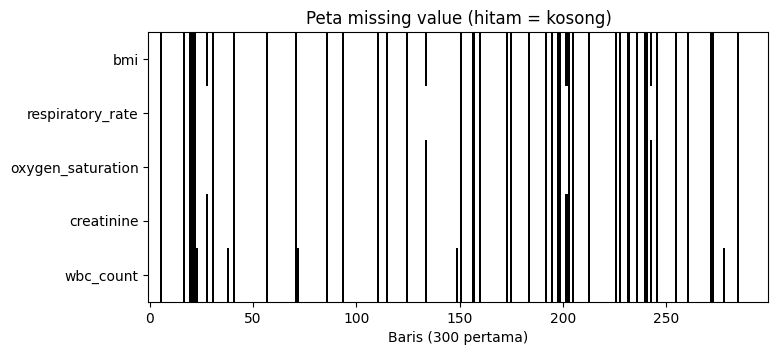

In [10]:
miss = pd.DataFrame({"jumlah": df.isna().sum(), "persen": (df.isna().mean() * 100).round(2)})
print(miss[miss["jumlah"] > 0])

print("\nJumlah kolom kosong per baris (dari 5 kolom missing):")
print(df[MISS_COLS].isna().sum(axis=1).value_counts().sort_index())

plt.figure(figsize=(8, 3.5))
plt.imshow(df[MISS_COLS].isna().values[:300].T, aspect="auto", cmap="gray_r", interpolation="nearest")
plt.yticks(range(len(MISS_COLS)), MISS_COLS)
plt.xlabel("Baris (300 pertama)")
plt.title("Peta missing value (hitam = kosong)")
plt.show()

In [11]:
# Menentukan jenis missing:
# - MAR  : missing berhubungan dengan variabel lain yang TERAMATI
# - MNAR : missing berhubungan dengan nilai itu sendiri (tidak bisa diuji langsung;
#          petunjuknya: hubungan dengan target)
# - MCAR : tidak ada hubungan sama sekali
tmp = df.copy()
tmp["ada_missing"] = tmp[MISS_COLS].isna().any(axis=1)

rows = []
for c in ["age", "severity_score", "heart_rate", "glucose", "ventilation_required",
          "chronic_conditions", "gender", "survived_icu"]:
    a = tmp.loc[tmp["ada_missing"], c].dropna()
    b = tmp.loc[~tmp["ada_missing"], c].dropna()
    t, p = stats.ttest_ind(a, b, equal_var=False)
    rows.append({"variabel": c, "mean_baris_missing": round(a.mean(), 3),
                 "mean_baris_lengkap": round(b.mean(), 3), "p_value": round(p, 4)})
pd.DataFrame(rows).set_index("variabel")

,mean_baris_missing,mean_baris_lengkap,p_value
variabel,,,
age,60.783,61.576,0.2230
severity_score,11.999,12.026,0.9228
heart_rate,100.743,98.883,0.5897
glucose,161.233,159.072,0.7160
ventilation_required,0.467,0.443,0.2228
chronic_conditions,1.652,1.617,0.5128
gender,0.537,0.531,0.7521
survived_icu,0.634,0.646,0.5152


**Interpretasi:** tidak ada p-value di bawah 0,05, jadi tidak ada bukti bahwa missing bergantung pada variabel lain yang teramati (bukan MAR) maupun pada target (tidak ada petunjuk MNAR). Pola ini **konsisten dengan MCAR** (missing acak, misalnya panel data yang gagal tercatat, terbukti dari 575 baris yang lima kolomnya kosong bersamaan). Perlu dicatat: MCAR/MNAR tidak bisa dibuktikan 100% dari data, hanya bisa didukung atau dibantah oleh uji seperti di atas.

Menurut slide, perlakuan untuk MCAR adalah **deletion**, tetapi di sini kehilangan 12% baris sekaligus cukup mahal, jadi di bagian 5.3 semua perlakuan (deletion, ignoring, imputation) dibandingkan secara empiris.

### 3.2 Duplikat, Noise/Outlier, dan Inkonsistensi

In [12]:
feature_cols = [c for c in df.columns if c not in ["patient_id", "survived_icu"]]
print("Duplikat patient_id              :", df["patient_id"].duplicated().sum())
print("Duplikat baris penuh             :", df.duplicated().sum())
print("Duplikat fitur+target (tanpa ID) :", df.duplicated(subset=feature_cols + ["survived_icu"]).sum())

Duplikat patient_id              : 0
Duplikat baris penuh             : 0
Duplikat fitur+target (tanpa ID) : 58


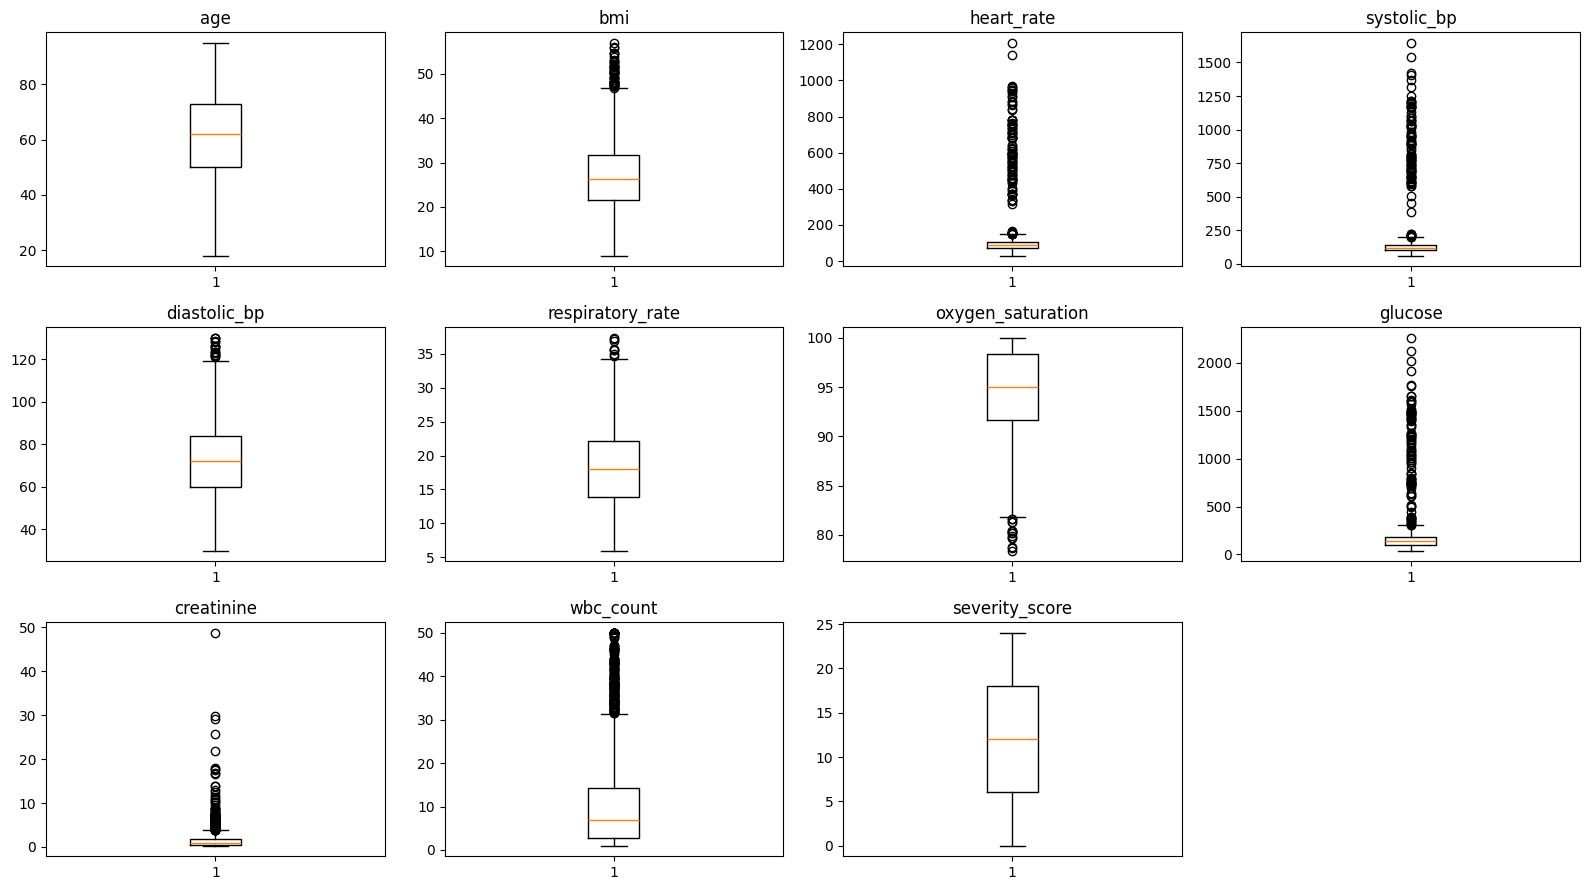

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, c in zip(axes.ravel(), NUM_COLS):
    ax.boxplot(df[c].dropna())
    ax.set_title(c)
for ax in axes.ravel()[len(NUM_COLS):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [14]:
# Rentang fisiologis yang masuk akal (domain knowledge)
RANGES = {
    "age": (18, 100), "bmi": (12, 60), "heart_rate": (30, 220),
    "systolic_bp": (60, 250), "diastolic_bp": (30, 150), "respiratory_rate": (5, 60),
    "oxygen_saturation": (50, 100), "glucose": (30, 600), "creatinine": (0.1, 15),
    "wbc_count": (0.5, 60),
}
rows = []
for c, (lo, hi) in RANGES.items():
    q1, q3 = df[c].quantile([0.25, 0.75]); iqr = q3 - q1
    rows.append({"kolom": c, "min": df[c].min(), "max": df[c].max(),
                 "rentang_valid": f"{lo}-{hi}",
                 "di_luar_rentang_valid": int(((df[c] < lo) | (df[c] > hi)).sum()),
                 "outlier_IQR": int(((df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)).sum()),
                 "skewness": round(df[c].skew(), 2)})
print(pd.DataFrame(rows).set_index("kolom"))

print("\nBaris dengan diastolic_bp >= systolic_bp (tidak logis):", (df["diastolic_bp"] >= df["systolic_bp"]).sum())
print("oxygen_saturation tepat 100 (capping alat ukur)       :", (df["oxygen_saturation"] == 100).sum())

                    min          max rentang_valid  di_luar_rentang_valid  outlier_IQR  skewness
kolom                                                                                           
age                18.0    95.000000        18-100                      0            0     -0.12
bmi                 9.0    57.000000         12-60                     33           47      0.51
heart_rate         30.0  1207.839980        30-220                     92          106      7.28
systolic_bp        60.0  1645.595945        60-250                     92          101      7.23
diastolic_bp       30.0   130.000000        30-150                      0           16      0.04
respiratory_rate    6.0    37.300000          5-60                      0            8      0.12
oxygen_saturation  78.4   100.000000        50-100                      0           15     -0.60
glucose            40.0  2256.210085        30-600                     79           95      6.94
creatinine          0.3    48.

### Ringkasan masalah dan rencana penanganan

| No | Masalah | Jenis (slide) | Penanganan | Bagian |
|----|---------|---------------|------------|--------|
| 1 | Nilai mustahil (HR > 1000, dst.) dan tekanan diastolik >= sistolik | Noise / Accuracy / Consistency | Aturan domain, jadikan NaN | 5.1 |
| 2 | Baris identik selain ID | Duplicate | `drop_duplicates` | 5.2 |
| 3 | Missing berkelompok | Missing (MCAR) | Bandingkan deletion, ignoring, imputasi | 5.3 |
| 4 | Nilai ekstrem sisa, distribusi miring | Outlier | Winsorizing, log, dsb. | 5.4 |
| 5 | Skala antar kolom beda jauh | Transformation | Scaling | 6.2 |
| 6 | Fitur kurang informatif | Feature engineering | Fitur turunan, seleksi, PCA | 6.6, 7 |

## 4. Split Data

Data dibagi **sebelum** preprocessing yang belajar dari data (imputasi, scaling, winsorizing, binning, seleksi fitur, PCA), supaya tidak terjadi *data leakage*. Aturan yang bersifat per baris dan tidak menghitung statistik (aturan domain, fitur turunan) aman dilakukan di mana saja.

In [15]:
X = df.drop(columns=["patient_id", "survived_icu"])
y = df["survived_icu"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Akurasi tebakan kelas mayoritas pada test:", round(y_test.value_counts(normalize=True).max(), 4))

Train: (3664, 14) | Test: (916, 14)
Akurasi tebakan kelas mayoritas pada test: 0.6441


In [16]:
# ---------- Fungsi bantu untuk eksperimen ----------
EXPERIMENT_LOG = []   # menyimpan semua hasil eksperimen untuk tabel ringkasan

def lr_model():  return LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
def rf_model():  return RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
def gb_model():  return GradientBoostingClassifier(random_state=RANDOM_STATE)
def knn_model(): return KNeighborsClassifier(n_neighbors=15)

def cv_acc(make_pipe, Xd, yd, row_filter=None, val_filter=None, n_splits=5):
    """5-fold stratified CV. make_pipe: fungsi yang mengembalikan pipeline baru.
    row_filter(X_trainfold) -> mask baris yang dipertahankan (dihitung hanya dari train fold).
    val_filter(X_valfold)   -> mask baris validasi yang dievaluasi (untuk listwise deletion)."""
    skf = StratifiedKFold(n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr, va in skf.split(Xd, yd):
        Xtr, ytr, Xva, yva = Xd.iloc[tr], yd.iloc[tr], Xd.iloc[va], yd.iloc[va]
        if row_filter is not None:
            keep = row_filter(Xtr)
            Xtr, ytr = Xtr[keep], ytr[keep]
        if val_filter is not None:
            keep = val_filter(Xva)
            Xva, yva = Xva[keep], yva[keep]
        pipe = make_pipe()
        pipe.fit(Xtr, ytr)
        scores.append(accuracy_score(yva, pipe.predict(Xva)))
    return float(np.mean(scores)), float(np.std(scores))

def log_result(tahap, variasi, mean, std):
    EXPERIMENT_LOG.append({"Tahap": tahap, "Variasi": variasi,
                           "CV accuracy": round(mean, 4), "Std": round(std, 4)})

## 5. Data Cleaning

### 5.1 Handling Noise (nilai tidak masuk akal)

Penyebab nilai salah menurut slide: alat ukur rusak, kesalahan input, gangguan transmisi. Nilai mustahil tidak bisa dipakai apa adanya, dan karena angka aslinya tidak diketahui, nilainya diubah menjadi **NaN** lalu ditangani bersama missing value. Barisnya tidak dibuang karena kolom lain pada baris itu masih valid.

In [17]:
def rule_based_clean(data):
    d = data.copy()
    # nilai di luar rentang fisiologis -> NaN
    for c, (lo, hi) in RANGES.items():
        d.loc[(d[c] < lo) | (d[c] > hi), c] = np.nan
    # diastolic >= systolic tidak logis; tidak diketahui mana yang salah -> keduanya NaN
    bad_bp = d["diastolic_bp"] >= d["systolic_bp"]
    d.loc[bad_bp, ["systolic_bp", "diastolic_bp"]] = np.nan
    return d

X_train_n = rule_based_clean(X_train)
X_test_n = rule_based_clean(X_test)

pd.DataFrame({"missing_sebelum": X_train[MEASURED].isna().sum(),
              "missing_sesudah_aturan_domain": X_train_n[MEASURED].isna().sum()})

,missing_sebelum,missing_sesudah_aturan_domain
bmi,492,520
heart_rate,0,77
systolic_bp,0,353
diastolic_bp,0,276
respiratory_rate,456,456
oxygen_saturation,479,479
glucose,0,64
creatinine,507,516
wbc_count,635,635


### 5.2 Removing Duplicate Data

Seperti pada slide, `drop_duplicates(subset=..., keep=...)` dipakai. Contoh kecil dahulu (data dari slide), lalu diterapkan pada data latih. Duplikat hanya dihapus dari **data latih**; test set dibiarkan apa adanya karena mewakili data nyata.

In [18]:
# Contoh dari slide
toy = pd.DataFrame({"brand": ["Yum Yum", "Yum Yum", "Indomie", "Indomie", "Indomie"],
                    "style": ["cup", "cup", "cup", "pack", "pack"],
                    "rating": [4, 4, 3.5, 15, 5]})
print("drop_duplicates():\n", toy.drop_duplicates())
print("\nsubset=['brand']:\n", toy.drop_duplicates(subset=["brand"]))
print("\nsubset=['brand','style'], keep='last':\n", toy.drop_duplicates(subset=["brand", "style"], keep="last"))

drop_duplicates():
      brand style  rating
0  Yum Yum   cup     4.0
2  Indomie   cup     3.5
3  Indomie  pack    15.0
4  Indomie  pack     5.0

subset=['brand']:
      brand style  rating
0  Yum Yum   cup     4.0
2  Indomie   cup     3.5

subset=['brand','style'], keep='last':
      brand style  rating
1  Yum Yum   cup     4.0
2  Indomie   cup     3.5
4  Indomie  pack     5.0


In [19]:
# Duplikat pada data latih (ID sudah dibuang, jadi baris identik = pasien tercatat ganda)
dup_mask = X_train.duplicated(keep="first")
print(f"Data latih: {len(X_train)} -> {(~dup_mask).sum()} baris ({dup_mask.sum()} duplikat dihapus)")

X_tr = X_train_n[~dup_mask].copy()
y_tr = y_train[~dup_mask].copy()
X_te, y_te = X_test_n.copy(), y_test.copy()

Data latih: 3664 -> 3627 baris (37 duplikat dihapus)


### 5.3 Handling Missing Value

Semua perlakuan dari slide dibandingkan memakai model Logistic Regression yang sama dan 5-fold CV pada data latih. Pipeline selalu menghitung statistik imputasi hanya dari train fold.

Fungsi pipeline utama (dipakai juga di bagian-bagian berikutnya) didefinisikan dulu.

In [20]:
SKEWED = ["glucose", "creatinine", "wbc_count"]

class Winsorizer(BaseEstimator, TransformerMixin):
    """Clip tiap kolom ke persentil bawah/atas dari data latih (NaN dipertahankan)."""
    def __init__(self, lower=1, upper=99):
        self.lower, self.upper = lower, upper
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lo_ = np.nanpercentile(X, self.lower, axis=0)
        self.hi_ = np.nanpercentile(X, self.upper, axis=0)
        return self
    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lo_, self.hi_)

class IQRClipper(BaseEstimator, TransformerMixin):
    """Clip ke [Q1 - k*IQR, Q3 + k*IQR] dari data latih."""
    def __init__(self, k=1.5):
        self.k = k
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        q1, q3 = np.nanpercentile(X, 25, axis=0), np.nanpercentile(X, 75, axis=0)
        iqr = q3 - q1
        self.lo_, self.hi_ = q1 - self.k * iqr, q3 + self.k * iqr
        return self
    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lo_, self.hi_)

def make_preprocessor(imputer=None, scaler=None, outlier="winsor", log=True):
    steps = []
    if log:   # transformasi log untuk kolom yang miring (NaN tetap NaN)
        steps.append(("log", ColumnTransformer(
            [("log", FunctionTransformer(np.log1p), SKEWED)], remainder="passthrough")))
    if outlier == "winsor":
        steps.append(("outlier", Winsorizer(1, 99)))
    elif outlier == "iqr":
        steps.append(("outlier", IQRClipper(1.5)))
    steps.append(("scale", scaler if scaler is not None else StandardScaler()))
    steps.append(("impute", imputer if imputer is not None else KNNImputer(n_neighbors=5)))
    return Pipeline(steps)

def add_missing_flags(d):
    """Fitur indikator missing (setara MissingIndicator): menyimpan informasi 'data ini tidak tercatat'."""
    d = d.copy()
    for c in MISS_COLS:
        d[f"{c}_missing"] = d[c].isna().astype(int)
    d["n_missing"] = d[MEASURED].isna().sum(axis=1)
    return d

def full_pipe(imputer=None, model_fn=lr_model, flags=False, **prep_kwargs):
    steps = []
    if flags:
        steps.append(("flags", FunctionTransformer(add_missing_flags)))
    steps.append(("prep", make_preprocessor(imputer=imputer, **prep_kwargs)))
    steps.append(("model", model_fn()))
    return Pipeline(steps)

**Deletion.** Dua jenis pertama (listwise dan pairwise) diperagakan dulu, lalu dihitung biaya kehilangan datanya.

In [21]:
# Listwise deletion: buang baris yang punya >= 1 missing
n_all = len(X_tr)
n_complete = X_tr.dropna().shape[0]
print(f"Listwise deletion: {n_all} -> {n_complete} baris ({100*(1-n_complete/n_all):.1f}% data hilang)")

# Pairwise deletion: hanya buang baris yang relevan untuk pasangan variabel yang dianalisis
pair = X_tr[["bmi", "age"]]
print("\nPairwise: korelasi bmi-age memakai", pair.dropna().shape[0], "baris pasangan (pandas .corr() melakukannya otomatis)")
print("Korelasi pairwise:", round(pair.corr().iloc[0, 1], 4))
print("Korelasi listwise (seluruh baris lengkap):", round(X_tr.dropna()[["bmi", "age"]].corr().iloc[0, 1], 4))

# Deleting columns: buang kolom dengan missing > 10%
miss_pct = X_tr.isna().mean()
cols_to_drop = miss_pct[miss_pct > 0.10].index.tolist()
print("\nKolom dengan missing > 10% :", cols_to_drop)

Listwise deletion: 3627 -> 2681 baris (26.1% data hilang)

Pairwise: korelasi bmi-age memakai 3107 baris pasangan (pandas .corr() melakukannya otomatis)
Korelasi pairwise: 0.0307
Korelasi listwise (seluruh baris lengkap): 0.0173

Kolom dengan missing > 10% : ['bmi', 'respiratory_rate', 'oxygen_saturation', 'creatinine', 'wbc_count']


**Imputasi dasar di pandas** seperti pada slide (`fillna`, forward fill, backward fill). `ffill`/`bfill` hanya masuk akal untuk data berurutan (time series); pada data pasien tidak berurutan ini hanya didemonstrasikan, tidak dipakai di model.

In [22]:
demo = X_tr[["bmi", "oxygen_saturation"]].head(8)
print("Asli:\n", demo)
print("\nfillna(0):\n", demo.fillna(0))
print("\nfillna(mean):\n", demo.fillna(demo.mean()).round(2))
print("\nffill (isi dari baris atas):\n", demo.ffill())
print("\nbfill (isi dari baris bawah):\n", demo.bfill())

Asli:
        bmi  oxygen_saturation
3355  25.7               93.7
2487   NaN                NaN
407    NaN               89.9
4313   NaN                NaN
1175  25.1               97.4
120   32.9               94.6
3922  23.3               93.5
2981  27.2              100.0

fillna(0):
        bmi  oxygen_saturation
3355  25.7               93.7
2487   0.0                0.0
407    0.0               89.9
4313   0.0                0.0
1175  25.1               97.4
120   32.9               94.6
3922  23.3               93.5
2981  27.2              100.0

fillna(mean):
         bmi  oxygen_saturation
3355  25.70              93.70
2487  26.84              94.85
407   26.84              89.90
4313  26.84              94.85
1175  25.10              97.40
120   32.90              94.60
3922  23.30              93.50
2981  27.20             100.00

ffill (isi dari baris atas):
        bmi  oxygen_saturation
3355  25.7               93.7
2487  25.7               93.7
407   25.7              

In [23]:
results = []

def add(variasi, mean, std, note=""):
    results.append({"Perlakuan missing": variasi, "CV accuracy": round(mean, 4), "Std": round(std, 4), "Catatan": note})
    log_result("5.3 Missing value", variasi, mean, std)

# --- DELETION ---
def complete_rows(d): return d.notna().all(axis=1)
m, s = cv_acc(lambda: Pipeline([("scale", StandardScaler()), ("model", lr_model())]),
              X_tr, y_tr, row_filter=complete_rows, val_filter=complete_rows)
add("Listwise deletion", m, s, "dievaluasi hanya pada baris lengkap (tidak setara dengan yang lain)")

def drop_cols(d): return d.drop(columns=cols_to_drop)
m, s = cv_acc(lambda: Pipeline([("drop", FunctionTransformer(drop_cols)), ("impute", SimpleImputer(strategy="median")),
                                ("scale", StandardScaler()), ("model", lr_model())]), X_tr, y_tr)
add("Hapus kolom missing > 10%", m, s, "sisa NaN diisi median")

# --- IGNORING: algoritma yang menangani NaN sendiri ---
m, s = cv_acc(lambda: Pipeline([("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))]), X_tr, y_tr)
add("Ignoring (HistGradientBoosting, NaN native)", m, s, "pohon keputusan menangani NaN sendiri")

# --- IMPUTATION ---
imputers = {
    "Imputasi konstanta 0":          SimpleImputer(strategy="constant", fill_value=0),
    "Imputasi mean":                 SimpleImputer(strategy="mean"),
    "Imputasi median":               SimpleImputer(strategy="median"),
    "Imputasi modus":                SimpleImputer(strategy="most_frequent"),
    "KNNImputer (k=5)":              KNNImputer(n_neighbors=5),
    "IterativeImputer":              IterativeImputer(max_iter=10, random_state=RANDOM_STATE),
}
for name, imp in imputers.items():
    m, s = cv_acc(lambda imp=imp: full_pipe(imputer=imp), X_tr, y_tr)
    add(name, m, s)

m, s = cv_acc(lambda: full_pipe(imputer=KNNImputer(n_neighbors=5), flags=True), X_tr, y_tr)
add("KNNImputer + indikator missing", m, s, "ditambah kolom *_missing dan n_missing")

pd.DataFrame(results).set_index("Perlakuan missing")

,CV accuracy,Std,Catatan
Perlakuan missing,,,
Listwise deletion,0.6611,0.0150,dievaluasi hanya pada baris lengkap (tidak set...
Hapus kolom missing > 10%,0.6686,0.0178,sisa NaN diisi median
"Ignoring (HistGradientBoosting, NaN native)",0.6419,0.0182,pohon keputusan menangani NaN sendiri
Imputasi konstanta 0,0.6667,0.0132,
Imputasi mean,0.6667,0.0132,
Imputasi median,0.6675,0.0134,
Imputasi modus,0.6672,0.0128,
KNNImputer (k=5),0.6650,0.0161,
IterativeImputer,0.6669,0.0133,


**Catatan membaca tabel:** selisih antar perlakuan umumnya lebih kecil daripada simpangan baku antar fold (kolom Std), sehingga tidak ada pemenang yang pasti. Itu wajar karena pola missing-nya MCAR dan kolom yang missing hampir tidak berkorelasi dengan target. Pemilihan akhir memakai **KNNImputer** karena mengisi nilai dari pasien yang paling mirip (memanfaatkan hubungan antar fitur, tidak mengerutkan variasi seperti mean/median), ditambah **indikator missing** agar informasi "tidak tercatat" tidak hilang. Listwise deletion tidak dipilih karena membuang seperempat data latih. Perlakuan "ignoring" (HistGradientBoosting) justru sedikit lebih rendah (sekitar 2 poin), kemungkinan karena model yang lebih fleksibel itu lebih mudah overfit pada data yang banyak noise.

### 5.4 Handling Outliers

Setelah noise mustahil dijadikan NaN, masih ada nilai ekstrem yang secara statistik menyimpang. Deteksi dengan dua metode: **IQR** dan **z-score**. Penanganan dibandingkan: tidak ditangani, hapus baris, clipping IQR, winsorizing, log transform, dan RobustScaler.

In [24]:
rows = []
for c in NUM_COLS:
    col = X_tr[c].dropna()
    q1, q3 = col.quantile([0.25, 0.75]); iqr = q3 - q1
    z = (col - col.mean()) / col.std()
    rows.append({"kolom": c,
                 "outlier_IQR (1.5xIQR)": int(((col < q1 - 1.5*iqr) | (col > q3 + 1.5*iqr)).sum()),
                 "outlier_zscore (|z|>3)": int((z.abs() > 3).sum()),
                 "skewness": round(col.skew(), 2)})
pd.DataFrame(rows).set_index("kolom")

,outlier_IQR (1.5xIQR),outlier_zscore (|z|>3),skewness
kolom,,,
age,0,0,-0.13
bmi,43,25,0.60
heart_rate,14,8,0.03
systolic_bp,11,6,0.21
diastolic_bp,15,9,0.01
respiratory_rate,7,3,0.12
oxygen_saturation,13,10,-0.62
glucose,17,12,0.49
creatinine,149,59,2.96


In [25]:
def zscore_filter(d, thr=3):
    sub = d[NUM_COLS]
    z = (sub - sub.mean()) / sub.std()
    return ((z.abs() <= thr) | z.isna()).all(axis=1)

med = lambda: SimpleImputer(strategy="median")
variants = {
    "Tidak ditangani":              dict(kw=dict(outlier=None, log=False)),
    "Hapus baris |z|>3":            dict(kw=dict(outlier=None, log=False), rf=zscore_filter),
    "Clipping IQR (1.5xIQR)":       dict(kw=dict(outlier="iqr", log=False)),
    "Winsorizing 1%-99%":           dict(kw=dict(outlier="winsor", log=False)),
    "Log1p (kolom miring)":         dict(kw=dict(outlier=None, log=True)),
    "Log1p + Winsorizing":          dict(kw=dict(outlier="winsor", log=True)),
    "RobustScaler (tanpa clipping)": dict(kw=dict(outlier=None, log=False, scaler=RobustScaler())),
}
rows = []
for name, cfg in variants.items():
    m, s = cv_acc(lambda cfg=cfg: full_pipe(imputer=med(), **cfg["kw"]), X_tr, y_tr, row_filter=cfg.get("rf"))
    rows.append({"Penanganan outlier": name, "CV accuracy": round(m, 4), "Std": round(s, 4)})
    log_result("5.4 Outlier", name, m, s)
pd.DataFrame(rows).set_index("Penanganan outlier")

,CV accuracy,Std
Penanganan outlier,,
Tidak ditangani,0.6667,0.0124
Hapus baris |z|>3,0.6692,0.0154
Clipping IQR (1.5xIQR),0.6669,0.0143
Winsorizing 1%-99%,0.6661,0.0135
Log1p (kolom miring),0.6675,0.0135
Log1p + Winsorizing,0.6675,0.0134
RobustScaler (tanpa clipping),0.6669,0.0122


Penanganan dipilih **log1p + winsorizing**: log mengurangi kemiringan pada glucose/creatinine/wbc_count, winsorizing memotong sisa nilai ekstrem tanpa membuang baris. Seperti sebelumnya, selisih antar variasi kecil karena kolom-kolom yang berisi outlier hampir tidak berkorelasi dengan target.

## 6. Data Transformation

### 6.1 Encoding Categorical Data

Dataset ini hampir seluruhnya numerik: `gender` dan `ventilation_required` sudah berupa 0/1. Agar teknik encoding dari slide (Label Encoder, One-hot Encoder, dan Ordinal) tetap dapat diperagakan, dibuat satu kolom kategorik dari BMI memakai kategori WHO (*attribute construction*).

In [26]:
bmi_labels = ["underweight", "normal", "overweight", "obese"]
bmi_cat = pd.cut(X_tr["bmi"], bins=[0, 18.5, 25, 30, 100], labels=bmi_labels, right=False)
demo = pd.DataFrame({"bmi": X_tr["bmi"], "bmi_category": bmi_cat}).dropna().head(8)
print(demo)

# 1) Label Encoder: label -> 0..n_classes-1 (urutan alfabet, TANPA makna urutan; cocok untuk target)
le = LabelEncoder().fit(demo["bmi_category"].astype(str))
print("\nLabelEncoder classes_:", list(le.classes_), "->", le.transform(le.classes_))

# 2) Ordinal Encoder: urutan ditentukan manual (untuk atribut ORDINAL)
oe = OrdinalEncoder(categories=[bmi_labels])
print("OrdinalEncoder (urutan manual):", oe.fit_transform(demo[["bmi_category"]].astype(str)).ravel())

# 3) One-hot Encoder: tiap kategori jadi kolom 0/1 (untuk atribut NOMINAL)
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
oh = ohe.fit_transform(demo[["bmi_category"]].astype(str))
print("\nOneHotEncoder:")
print(pd.DataFrame(oh, columns=ohe.get_feature_names_out(["bmi_category"]), index=demo.index))

# One-hot untuk gender (nominal). drop='first' menghindari kolom redundan
print("\nGender one-hot (drop='first'):",
      OneHotEncoder(drop="first", sparse_output=False).fit_transform(X_tr[["gender"]])[:5].ravel())

       bmi bmi_category
3355  25.7   overweight
1175  25.1   overweight
120   32.9        obese
3922  23.3       normal
2981  27.2   overweight
1813  27.3   overweight
2588  29.1   overweight
2365  23.0       normal

LabelEncoder classes_: ['normal', 'obese', 'overweight'] -> [0 1 2]
OrdinalEncoder (urutan manual): [2. 2. 3. 1. 2. 2. 2. 1.]

OneHotEncoder:
      bmi_category_normal  bmi_category_obese  bmi_category_overweight
3355                  0.0                 0.0                      1.0
1175                  0.0                 0.0                      1.0
120                   0.0                 1.0                      0.0
3922                  1.0                 0.0                      0.0
2981                  0.0                 0.0                      1.0
1813                  0.0                 0.0                      1.0
2588                  0.0                 0.0                      1.0
2365                  1.0                 0.0                      0.0

G

**Kapan memakai apa:** one-hot untuk nominal (tidak ada urutan), ordinal encoder untuk ordinal (ada urutan), label encoder terutama untuk target. `gender` dan `ventilation_required` sudah biner 0/1 sehingga setara dengan one-hot `drop='first'` dan tidak perlu diubah.

### 6.2 Feature Scaling

Slide: tanpa scaling, fitur dengan rentang besar mendominasi model berbasis jarak/gradien. Teknik yang dicakup: **min-max**, **z-score**, **unit conversion**, dan **decimal scaling**, ditambah tiga transformer yang disebut di daftar estimator slide (RobustScaler, PowerTransformer, QuantileTransformer).

In [27]:
# Unit conversion: mg/dL -> satuan SI agar sebanding dengan literatur lain
glucose_mmol = X_tr["glucose"] / 18.016        # mg/dL -> mmol/L
creat_umol = X_tr["creatinine"] * 88.4         # mg/dL -> umol/L
print(pd.DataFrame({"glucose mg/dL": X_tr["glucose"].head(5), "glucose mmol/L": glucose_mmol.head(5).round(2),
                    "creatinine mg/dL": X_tr["creatinine"].head(5), "creatinine umol/L": creat_umol.head(5).round(1)}))

      glucose mg/dL  glucose mmol/L  creatinine mg/dL  creatinine umol/L
3355          178.0            9.88              1.59              140.6
2487          150.1            8.33               NaN                NaN
407           145.2            8.06               NaN                NaN
4313          242.3           13.45               NaN                NaN
1175          129.8            7.20              0.30               26.5


In [28]:
class DecimalScaler(BaseEstimator, TransformerMixin):
    """Decimal scaling: v' = v / 10^j, j = bilangan bulat terkecil sehingga max(|v'|) < 1."""
    def fit(self, X, y=None):
        m = np.nanmax(np.abs(np.asarray(X, dtype=float)), axis=0)
        self.j_ = np.where(m > 0, np.floor(np.log10(m)) + 1, 0)
        return self
    def transform(self, X):
        return np.asarray(X, dtype=float) / (10.0 ** self.j_)

# Peragaan rumus pada satu kolom (age)
a = X_tr[["age"]]
print(pd.DataFrame({
    "asli": a["age"].head(5),
    "min-max":  MinMaxScaler().fit_transform(a)[:5, 0].round(3),
    "z-score":  StandardScaler().fit_transform(a)[:5, 0].round(3),
    "decimal":  DecimalScaler().fit_transform(a)[:5, 0].round(3),
}))
print("\nCek rumus min-max manual :", round((a['age'].iloc[0]-a['age'].min())/(a['age'].max()-a['age'].min()), 3))
print("Cek rumus z-score manual :", round((a['age'].iloc[0]-a['age'].mean())/a['age'].std(ddof=0), 3))

      asli  min-max  z-score  decimal
3355  71.0    0.688    0.559     0.71
2487  26.0    0.104   -2.070     0.26
407   65.0    0.610    0.209     0.65
4313  53.0    0.455   -0.492     0.53
1175  37.0    0.247   -1.427     0.37

Cek rumus min-max manual : 0.688
Cek rumus z-score manual : 0.559


In [29]:
scalers = {
    "Tanpa scaling":       "passthrough",
    "Min-Max":             MinMaxScaler(),
    "Z-score (Standard)":  StandardScaler(),
    "Decimal scaling":     DecimalScaler(),
    "RobustScaler":        RobustScaler(),
    "PowerTransformer":    PowerTransformer(),
    "QuantileTransformer": QuantileTransformer(n_quantiles=200, output_distribution="normal", random_state=RANDOM_STATE),
}
models = {"Logistic Regression": lr_model, "KNN (k=15)": knn_model, "Random Forest": rf_model}

def scale_pipe(scaler, model_fn):
    return Pipeline([("impute", SimpleImputer(strategy="median")), ("winsor", Winsorizer(1, 99)),
                     ("scale", scaler), ("model", model_fn())])

rows = []
for sname, sc in scalers.items():
    row = {"Scaler": sname}
    for mname, mf in models.items():
        m, s = cv_acc(lambda sc=sc, mf=mf: scale_pipe(sc, mf), X_tr, y_tr)
        row[mname] = round(m, 4)
        log_result("6.2 Scaling", f"{sname} + {mname}", m, s)
    rows.append(row)
pd.DataFrame(rows).set_index("Scaler")

,Logistic Regression,KNN (k=15),Random Forest
Scaler,,,
Tanpa scaling,0.6656,0.6187,0.6543
Min-Max,0.6658,0.6402,0.6551
Z-score (Standard),0.6661,0.6341,0.6565
Decimal scaling,0.6681,0.6421,0.6551
RobustScaler,0.6661,0.6317,0.6556
PowerTransformer,0.6689,0.6402,0.6559
QuantileTransformer,0.6529,0.6198,0.6565


**Pengamatan:** scaling paling berpengaruh pada **KNN** (model berbasis jarak): tanpa scaling accuracy-nya sekitar 0,62, dengan scaling naik menjadi sekitar 0,63-0,64 (kolom bernilai besar seperti glucose dan wbc_count mendominasi jarak jika tidak diskalakan). Pada Logistic Regression dan Random Forest perubahannya kecil dan masih dalam rentang Std. Random Forest memang tidak sensitif skala karena pohon hanya membandingkan urutan nilai, bukan besarnya. Ini cocok dengan slide: *different models may require different preprocessing*. Untuk model akhir dipakai **z-score (StandardScaler)**, karena standar untuk Logistic Regression dan juga dibutuhkan KNNImputer (menghitung jarak).

### 6.3 Smoothing (binning)

Smoothing meredam *noise* kecil. Cara klasik: bagi nilai ke dalam bin (equal-depth), lalu ganti tiap nilai dengan **rata-rata bin**-nya (*smoothing by bin means*).

In [30]:
hr = X_tr["heart_rate"].dropna()
bins = pd.qcut(hr, q=10, duplicates="drop")
hr_smooth = hr.groupby(bins).transform("mean")

print(pd.DataFrame({"heart_rate asli": hr.head(8), "smoothing by bin mean": hr_smooth.head(8).round(1)}))
print(f"\nStd sebelum: {hr.std():.2f} | sesudah: {hr_smooth.std():.2f} | nilai unik: {hr.nunique()} -> {hr_smooth.nunique()}")

      heart_rate asli  smoothing by bin mean
3355             91.7                   91.4
2487             56.8                   50.9
407              85.1                   85.9
4313            111.8                  110.5
1175             66.9                   65.7
120              91.7                   91.4
3922             95.1                   97.0
2981            109.3                  110.5

Std sebelum: 21.51 | sesudah: 21.07 | nilai unik: 914 -> 10


### 6.4 Aggregation

Menggabungkan objek menjadi satu: pasien individual diringkas per kelompok usia / jumlah penyakit kronis. Tujuannya mengurangi jumlah objek, mengubah skala (individu -> kelompok), dan melihat pola yang lebih stabil.

               jumlah_pasien  survival_rate  rata2_severity  persen_ventilator
kelompok_usia                                                                 
18-40                    421          0.798          12.038              0.432
41-55                    894          0.735          11.841              0.460
56-65                    804          0.647          12.532              0.434
66-75                    741          0.592          12.090              0.449
>75                      767          0.506          12.034              0.445


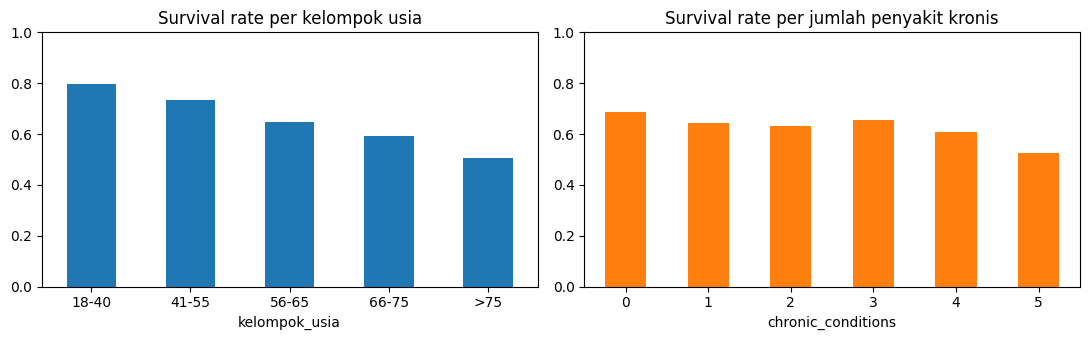

In [31]:
train_view = X_tr.assign(survived_icu=y_tr)
train_view["kelompok_usia"] = pd.cut(train_view["age"], bins=[17, 40, 55, 65, 75, 100],
                                     labels=["18-40", "41-55", "56-65", "66-75", ">75"])

agg_age = train_view.groupby("kelompok_usia", observed=True).agg(
    jumlah_pasien=("age", "size"),
    survival_rate=("survived_icu", "mean"),
    rata2_severity=("severity_score", "mean"),
    persen_ventilator=("ventilation_required", "mean")).round(3)
print(agg_age)

agg_chronic = train_view.groupby("chronic_conditions").agg(
    jumlah_pasien=("age", "size"), survival_rate=("survived_icu", "mean")).round(3)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
agg_age["survival_rate"].plot(kind="bar", ax=ax[0], color="tab:blue", rot=0)
ax[0].set_title("Survival rate per kelompok usia"); ax[0].set_ylim(0, 1)
agg_chronic["survival_rate"].plot(kind="bar", ax=ax[1], color="tab:orange", rot=0)
ax[1].set_title("Survival rate per jumlah penyakit kronis"); ax[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

### 6.5 Discretization

Mengubah atribut kontinu menjadi interval. Empat metode dari slide diterapkan pada `age`:
1. **Equal-width**: lebar interval sama, `W = (B - A) / N`
2. **Equal-depth (frequency)**: jumlah sampel per interval hampir sama
3. **Cluster analysis**: batas ditentukan oleh k-means
4. **Entropy-based (supervised)**: batas dipilih agar tiap interval sebisa mungkin murni terhadap target (pohon keputusan dengan kriteria entropy)

In [32]:
class EntropyBinner(BaseEstimator, TransformerMixin):
    """Diskretisasi supervised: batas bin = threshold pohon keputusan (criterion='entropy').
    Keluaran: one-hot dari bin. Batas dipelajari hanya dari data latih."""
    def __init__(self, max_bins=5, min_samples_leaf=100):
        self.max_bins, self.min_samples_leaf = max_bins, min_samples_leaf
    def fit(self, X, y):
        X = np.asarray(X, dtype=float); y = np.asarray(y)
        self.edges_ = []
        for j in range(X.shape[1]):
            col = X[:, j]; ok = ~np.isnan(col)
            tree = DecisionTreeClassifier(criterion="entropy", max_leaf_nodes=self.max_bins,
                                          min_samples_leaf=self.min_samples_leaf, random_state=0)
            tree.fit(col[ok].reshape(-1, 1), y[ok])
            thr = tree.tree_.threshold[tree.tree_.feature >= 0]
            self.edges_.append(np.sort(thr))
        return self
    def transform(self, X):
        X = np.asarray(X, dtype=float)
        out = [np.eye(len(e) + 1)[np.digitize(X[:, j], e)] for j, e in enumerate(self.edges_)]
        return np.hstack(out)

age_tr = X_tr[["age"]]
edges = {}
bin_index = {}
for name, strat in [("Equal-width", "uniform"), ("Equal-depth", "quantile"), ("Cluster (k-means)", "kmeans")]:
    kb = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy=strat, random_state=RANDOM_STATE)
    bin_index[name] = kb.fit_transform(age_tr).ravel().astype(int)
    edges[name] = np.round(kb.bin_edges_[0], 1)

eb = EntropyBinner(max_bins=5).fit(age_tr, y_tr)
edges["Entropy-based (supervised)"] = np.round(eb.edges_[0], 1)
bin_index["Entropy-based (supervised)"] = np.digitize(age_tr["age"].values, eb.edges_[0])

for name in edges:
    print(f"\n{name}\n  batas: {edges[name]}")
    tab = pd.DataFrame({"bin": bin_index[name], "y": y_tr.values}).groupby("bin").agg(
        jumlah=("y", "size"), survival_rate=("y", "mean")).round(3)
    print(tab.T.to_string())


Equal-width
  batas: [18.  33.4 48.8 64.2 79.6 95. ]
bin                  0        1         2         3        4
jumlah         213.000  615.000  1201.000  1042.000  556.000
survival_rate    0.822    0.763     0.673     0.591    0.489

Equal-depth
  batas: [18. 47. 57. 66. 76. 95.]
bin                  0        1       2        3        4
jumlah         714.000  660.000  745.00  741.000  767.000
survival_rate    0.782    0.724    0.64    0.592    0.506

Cluster (k-means)
  batas: [18.  35.8 50.8 64.4 79.4 95. ]
bin                  0        1        2         3        4
jumlah         249.000  697.000  1083.00  1042.000  556.000
survival_rate    0.823    0.763     0.66     0.591    0.489

Entropy-based (supervised)
  batas: [50.5 56.5 65.5 82.5]
bin                  0        1       2         3        4
jumlah         946.000  428.000  745.00  1089.000  419.000
survival_rate    0.779    0.699    0.64     0.582    0.461


In [33]:
# Pengaruh diskretisasi terhadap model: ganti `age` dengan one-hot bin-nya
def disc_pipe(kind, model_fn=lr_model):
    if kind == "raw":
        step = ColumnTransformer([("age", "passthrough", ["age"])], remainder="passthrough")
    elif kind == "entropy":
        step = ColumnTransformer([("age", EntropyBinner(5), ["age"])], remainder="passthrough")
    else:
        step = ColumnTransformer([("age", KBinsDiscretizer(n_bins=5, encode="onehot-dense", strategy=kind,
                                                           random_state=RANDOM_STATE), ["age"])],
                                 remainder="passthrough")
    return Pipeline([("disc", step), ("impute", SimpleImputer(strategy="median")),
                     ("winsor", Winsorizer(1, 99)), ("scale", StandardScaler()), ("model", model_fn())])

rows = []
for label, kind in [("age asli (tanpa diskretisasi)", "raw"), ("Equal-width", "uniform"),
                    ("Equal-depth", "quantile"), ("Cluster (k-means)", "kmeans"), ("Entropy-based", "entropy")]:
    row = {"Perlakuan age": label}
    for mname, mf in [("Logistic Regression", lr_model), ("Random Forest", rf_model)]:
        m, s = cv_acc(lambda kind=kind, mf=mf: disc_pipe(kind, mf), X_tr, y_tr)
        row[mname] = round(m, 4)
        log_result("6.5 Diskretisasi", f"{label} + {mname}", m, s)
    rows.append(row)
pd.DataFrame(rows).set_index("Perlakuan age")

,Logistic Regression,Random Forest
Perlakuan age,,
age asli (tanpa diskretisasi),0.6661,0.6565
Equal-width,0.6658,0.6589
Equal-depth,0.6692,0.6529
Cluster (k-means),0.6661,0.6554
Entropy-based,0.6683,0.6548


**Pengamatan:** diskretisasi menghilangkan sebagian informasi (usia 61 dan 62 jadi sama), sehingga pada data yang punya hubungan monoton kuat seperti usia vs survival, hasilnya biasanya tidak lebih baik dari atribut kontinu. Manfaat utamanya adalah **interpretabilitas** (lihat tabel survival rate per bin) dan kebutuhan algoritma yang hanya menerima atribut kategorik. Karena itu `age` tetap dipakai kontinu di model akhir.

### 6.6 Feature Engineering

Kelima jenis dari slide:

| Jenis | Penerapan |
|---|---|
| a) Feature extraction | `pulse_pressure` (sistolik - diastolik), `map` (mean arterial pressure), `shock_index` (HR / sistolik) |
| b) Feature encoding | Bagian 6.1 (one-hot, ordinal, label) dan indikator missing (5.3) |
| c) Feature scaling | Bagian 6.2 |
| d) Feature selection | Bagian 7.1 |
| e) Feature combination | `age_x_severity`, `vent_x_severity` (interaksi dua variabel) |

In [34]:
def add_extraction(d):
    d = d.copy()
    d["pulse_pressure"] = d["systolic_bp"] - d["diastolic_bp"]
    d["map"] = (d["systolic_bp"] + 2 * d["diastolic_bp"]) / 3
    d["shock_index"] = d["heart_rate"] / d["systolic_bp"]
    return d

def add_combination(d):
    d = d.copy()
    d["age_x_severity"] = d["age"] * d["severity_score"]
    d["vent_x_severity"] = d["ventilation_required"] * d["severity_score"]
    return d

def fe_pipe(extract=False, combine=False, flags=False, model_fn=lr_model):
    steps = []
    if extract: steps.append(("extract", FunctionTransformer(add_extraction)))
    if combine: steps.append(("combine", FunctionTransformer(add_combination)))
    if flags:   steps.append(("flags", FunctionTransformer(add_missing_flags)))
    steps.append(("prep", make_preprocessor(imputer=KNNImputer(n_neighbors=5))))
    steps.append(("model", model_fn()))
    return Pipeline(steps)

fe_variants = {
    "Tanpa fitur baru":                   dict(),
    "+ extraction":                       dict(extract=True),
    "+ combination":                      dict(combine=True),
    "+ indikator missing":                dict(flags=True),
    "+ semuanya":                         dict(extract=True, combine=True, flags=True),
}
rows = []
for name, kw in fe_variants.items():
    row = {"Fitur": name}
    for mname, mf in [("Logistic Regression", lr_model), ("Gradient Boosting", gb_model)]:
        m, s = cv_acc(lambda kw=kw, mf=mf: fe_pipe(model_fn=mf, **kw), X_tr, y_tr)
        row[mname] = round(m, 4)
        log_result("6.6 Feature engineering", f"{name} + {mname}", m, s)
    rows.append(row)
pd.DataFrame(rows).set_index("Fitur")

,Logistic Regression,Gradient Boosting
Fitur,,
Tanpa fitur baru,0.6650,0.6559
+ extraction,0.6675,0.6507
+ combination,0.6697,0.6515
+ indikator missing,0.6653,0.6510
+ semuanya,0.6661,0.6576


**Pengamatan:** fitur interaksi `age_x_severity` ternyata punya korelasi dengan target yang lebih kuat (sekitar -0,24) daripada `age` (-0,20) atau `severity_score` (-0,15) sendirian, jadi ini fitur yang benar-benar membawa informasi. Namun peningkatan accuracy pada Logistic Regression hanya sekitar 0,2-0,5 poin (di dalam Std), dan pada Gradient Boosting tidak konsisten. Fitur turunan dari kolom yang noise (`pulse_pressure`, `map`, `shock_index`) tidak membantu karena kolom asalnya memang tidak prediktif.

## 7. Data Reduction

### 7.1 Variable Selection

Tiga pendekatan: (1) **domain knowledge** (buang `patient_id`, sudah dilakukan), (2) **filter statistik** (korelasi, mutual information, variance threshold), (3) **berbasis model** (importance Random Forest). Fitur yang dipakai di sini adalah semua fitur setelah feature engineering.

In [35]:
# Dataset dengan semua fitur turunan, imputasi median agar bisa dihitung statistiknya (hanya data latih)
X_fe = add_missing_flags(add_combination(add_extraction(X_tr)))
X_fe_imp = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_fe), columns=X_fe.columns, index=X_fe.index)
print("Jumlah fitur:", X_fe.shape[1])

# (a) Korelasi dengan target dan redundansi antar fitur
corr_target = X_fe_imp.corrwith(y_tr).sort_values(key=np.abs, ascending=False).round(3)
print("Korelasi dengan target (5 teratas):\n", corr_target.head(5))

cm = X_fe_imp.corr().abs()
pairs = [(a, b, round(cm.loc[a, b], 2)) for i, a in enumerate(cm.columns) for b in cm.columns[i+1:] if cm.loc[a, b] > 0.8]
print("\nPasangan fitur redundan (|r| > 0.8):")
for p in pairs: print("  ", p)

Jumlah fitur: 25
Korelasi dengan target (5 teratas):
 age_x_severity         -0.236
age                    -0.204
severity_score         -0.154
vent_x_severity        -0.126
ventilation_required   -0.068
dtype: float64

Pasangan fitur redundan (|r| > 0.8):
   ('systolic_bp', 'pulse_pressure', np.float64(0.82))
   ('diastolic_bp', 'map', np.float64(0.81))
   ('severity_score', 'age_x_severity', np.float64(0.88))
   ('bmi_missing', 'respiratory_rate_missing', np.float64(0.93))
   ('bmi_missing', 'oxygen_saturation_missing', np.float64(0.95))
   ('bmi_missing', 'creatinine_missing', np.float64(0.94))
   ('bmi_missing', 'wbc_count_missing', np.float64(0.83))
   ('bmi_missing', 'n_missing', np.float64(0.9))
   ('respiratory_rate_missing', 'oxygen_saturation_missing', np.float64(0.97))
   ('respiratory_rate_missing', 'creatinine_missing', np.float64(0.93))
   ('respiratory_rate_missing', 'wbc_count_missing', np.float64(0.82))
   ('respiratory_rate_missing', 'n_missing', np.float64(0.9))
   (

                  mutual_info  RF_importance
age_x_severity         0.0340         0.0902
age                    0.0276         0.0788
heart_rate             0.0000         0.0635
glucose                0.0140         0.0624
map                    0.0081         0.0594
respiratory_rate       0.0000         0.0588
pulse_pressure         0.0012         0.0584
diastolic_bp           0.0001         0.0579
systolic_bp            0.0089         0.0572
shock_index            0.0000         0.0568
bmi                    0.0123         0.0564
wbc_count              0.0147         0.0535

VarianceThreshold (0.01, skala min-max) membuang: ['creatinine']


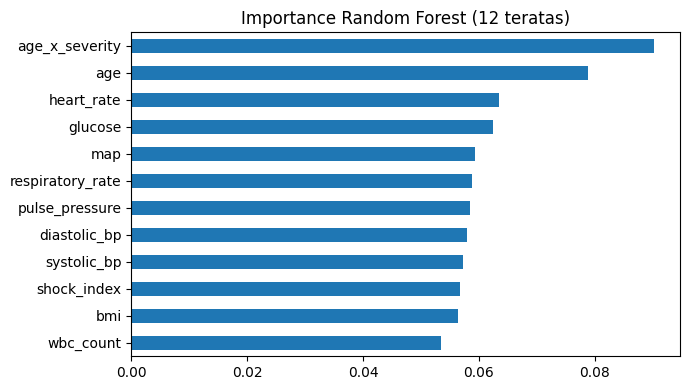

In [36]:
# (b) Mutual information + (c) Random Forest importance + (d) VarianceThreshold
mi = pd.Series(mutual_info_classif(X_fe_imp, y_tr, random_state=RANDOM_STATE), index=X_fe_imp.columns)
rf_imp = pd.Series(RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(X_fe_imp, y_tr)
                   .feature_importances_, index=X_fe_imp.columns)

ranking = pd.DataFrame({"mutual_info": mi.round(4), "RF_importance": rf_imp.round(4)}).sort_values("RF_importance", ascending=False)
print(ranking.head(12))

scaled = pd.DataFrame(MinMaxScaler().fit_transform(X_fe_imp), columns=X_fe_imp.columns)
vt = VarianceThreshold(threshold=0.01).fit(scaled)
print("\nVarianceThreshold (0.01, skala min-max) membuang:", list(scaled.columns[~vt.get_support()]))

ranking["RF_importance"].head(12).iloc[::-1].plot(kind="barh", figsize=(7, 4), title="Importance Random Forest (12 teratas)")
plt.tight_layout(); plt.show()

**Pengamatan seleksi fitur:**
- **Redundansi:** kelima indikator `*_missing` dan `n_missing` berkorelasi 0,83-0,97 satu sama lain, karena missing-nya berkelompok. Dalam praktik cukup satu (misalnya `n_missing`). Fitur turunan juga redundan dengan asalnya (`pulse_pressure` dengan `systolic_bp`, `map` dengan `diastolic_bp`).
- **Dua kriteria bisa berbeda:** mutual information menilai `age_x_severity` dan `age` tertinggi (dan banyak kolom bernilai 0), sedangkan importance Random Forest hampir rata di semua kolom kontinu. Importance RF cenderung menyebar ke fitur kontinu yang berisi noise karena pohon bisa memotong di titik acak, jadi jangan dibaca sebagai bukti bahwa kolom itu prediktif.
- **VarianceThreshold sensitif skala dan outlier:** `creatinine` terbuang karena outlier ekstrem membuat variansi min-max-nya kecil, bukan karena tidak informatif. Ini contoh bahwa filter variansi sebaiknya dijalankan setelah outlier ditangani.

In [37]:
# Apakah memilih top-k fitur membantu? Seleksi berada DI DALAM pipeline (tanpa leakage).
def sel_pipe(k, model_fn=lr_model):
    steps = [("extract", FunctionTransformer(add_extraction)), ("combine", FunctionTransformer(add_combination)),
             ("flags", FunctionTransformer(add_missing_flags)), ("prep", make_preprocessor(imputer=KNNImputer(n_neighbors=5)))]
    if k is not None:
        steps.append(("select", SelectKBest(lambda a, b: mutual_info_classif(a, b, random_state=RANDOM_STATE), k=k)))
    steps.append(("model", model_fn()))
    return Pipeline(steps)

rows = []
for k in [4, 6, 8, 12, None]:
    m, s = cv_acc(lambda k=k: sel_pipe(k), X_tr, y_tr)
    label = f"Top-{k} (mutual information)" if k else f"Semua fitur ({X_fe.shape[1]})"
    rows.append({"Seleksi fitur": label, "CV accuracy (LR)": round(m, 4), "Std": round(s, 4)})
    log_result("7.1 Seleksi fitur", label, m, s)
pd.DataFrame(rows).set_index("Seleksi fitur")

,CV accuracy (LR),Std
Seleksi fitur,,
Top-4 (mutual information),0.6634,0.0112
Top-6 (mutual information),0.6667,0.0102
Top-8 (mutual information),0.6672,0.0109
Top-12 (mutual information),0.6700,0.0121
Semua fitur (25),0.6661,0.0148


### 7.2 Variable Reduction (PCA)

PCA menggabungkan fitur berkorelasi menjadi sejumlah komponen yang menyimpan sebagian besar variansi. Berbeda dari seleksi, PCA **membentuk fitur baru** (kurang interpretabel).

Komponen untuk 90% variansi: 13 | 95%: 15 | total fitur: 25


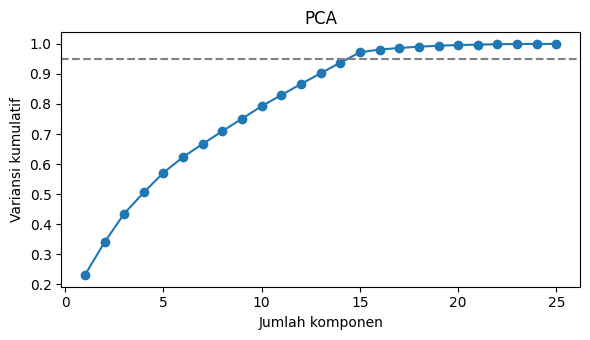

In [38]:
prep_pca = make_preprocessor(imputer=KNNImputer(n_neighbors=5))
Z = prep_pca.fit_transform(add_missing_flags(add_combination(add_extraction(X_tr))))
pca = PCA().fit(Z)
cum = np.cumsum(pca.explained_variance_ratio_)
print("Komponen untuk 90% variansi:", int(np.argmax(cum >= 0.90)) + 1, "| 95%:", int(np.argmax(cum >= 0.95)) + 1, "| total fitur:", Z.shape[1])

plt.figure(figsize=(6, 3.5))
plt.plot(range(1, len(cum) + 1), cum, marker="o")
plt.axhline(0.95, color="gray", linestyle="--")
plt.xlabel("Jumlah komponen"); plt.ylabel("Variansi kumulatif"); plt.title("PCA")
plt.tight_layout(); plt.show()

In [39]:
def pca_pipe(n):
    steps = [("extract", FunctionTransformer(add_extraction)), ("combine", FunctionTransformer(add_combination)),
             ("flags", FunctionTransformer(add_missing_flags)), ("prep", make_preprocessor(imputer=KNNImputer(n_neighbors=5)))]
    if n is not None:
        steps.append(("pca", PCA(n_components=n, random_state=RANDOM_STATE)))
    steps.append(("model", lr_model()))
    return Pipeline(steps)

rows = []
for n, label in [(5, "PCA 5 komponen"), (8, "PCA 8 komponen"), (0.95, "PCA 95% variansi"), (None, "Tanpa PCA")]:
    m, s = cv_acc(lambda n=n: pca_pipe(n), X_tr, y_tr)
    rows.append({"Reduksi": label, "CV accuracy (LR)": round(m, 4), "Std": round(s, 4)})
    log_result("7.2 PCA", label, m, s)
pd.DataFrame(rows).set_index("Reduksi")

,CV accuracy (LR),Std
Reduksi,,
PCA 5 komponen,0.6587,0.0110
PCA 8 komponen,0.6617,0.0053
PCA 95% variansi,0.6714,0.0108
Tanpa PCA,0.6661,0.0148


**Pengamatan:** karena fitur prediktif di dataset ini sedikit (age, severity_score, ventilation, chronic_conditions) dan fitur lain hampir berupa noise, seleksi/reduksi umumnya tidak menaikkan accuracy secara berarti, tetapi membuat model lebih ringkas. Keputusan akhir ditentukan di bagian 8 berdasarkan hasil di atas.

## 8. Pipeline Akhir, Modeling, dan Evaluasi

Gabungan semua langkah yang dipilih, dalam satu pipeline:

1. Aturan domain (noise -> NaN) dan hapus duplikat (data latih)
2. Feature extraction + combination + indikator missing
3. Log1p (kolom miring) -> Winsorizing 1%-99% -> StandardScaler -> KNNImputer (k=5)
4. Model: Logistic Regression, Random Forest, Gradient Boosting

Seleksi fitur dan PCA **tidak** dimasukkan karena tidak memberi peningkatan yang jelas (lihat bagian 7).

In [40]:
def final_pipe(model_fn):
    return Pipeline([
        ("extract", FunctionTransformer(add_extraction)),
        ("combine", FunctionTransformer(add_combination)),
        ("flags",   FunctionTransformer(add_missing_flags)),
        ("prep",    make_preprocessor(imputer=KNNImputer(n_neighbors=5), outlier="winsor", log=True)),
        ("model",   model_fn()),
    ])

def metrics(pipe, Xtr, ytr, Xte, yte):
    pipe.fit(Xtr, ytr)
    pred, proba = pipe.predict(Xte), pipe.predict_proba(Xte)[:, 1]
    return {"Accuracy": accuracy_score(yte, pred), "Precision": precision_score(yte, pred),
            "Recall": recall_score(yte, pred), "F1": f1_score(yte, pred),
            "ROC-AUC": roc_auc_score(yte, proba)}, pred

final_models = {"Logistic Regression": lr_model, "Random Forest": rf_model, "Gradient Boosting": gb_model}

# Baseline: data kotor asli, hanya imputasi median
base_res, final_res, final_pred = {}, {}, {}
for name, mf in final_models.items():
    base_pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("model", mf())])
    base_res[name], _ = metrics(base_pipe, X_train, y_train, X_test, y_test)
    final_res[name], final_pred[name] = metrics(final_pipe(mf), X_tr, y_tr, X_te, y_te)

comparison = pd.concat({"Sebelum (data kotor)": pd.DataFrame(base_res).T,
                        "Sesudah (pipeline lengkap)": pd.DataFrame(final_res).T}, axis=1).round(4)
print("Accuracy tebakan kelas mayoritas:", round(y_test.value_counts(normalize=True).max(), 4))
comparison

Accuracy tebakan kelas mayoritas: 0.6441


Sebelum (data kotor)                                   Sesudah (pipeline lengkap)                                  
                                Accuracy Precision  Recall      F1 ROC-AUC                   Accuracy Precision  Recall      F1 ROC-AUC
Logistic Regression               0.6779    0.6874  0.9169  0.7858  0.6727                     0.6670    0.6834  0.9000  0.7769  0.6749
Random Forest                     0.6736    0.6877  0.9034  0.7810  0.6649                     0.6736    0.6974  0.8712  0.7747  0.6475
Gradient Boosting                 0.6627    0.6827  0.8898  0.7726  0.6528                     0.6561    0.6788  0.8847  0.7682  0.6514

                     Sebelum  Sesudah  Selisih
Logistic Regression   0.6779   0.6670  -0.0109
Random Forest         0.6736   0.6736   0.0000
Gradient Boosting     0.6627   0.6561  -0.0066


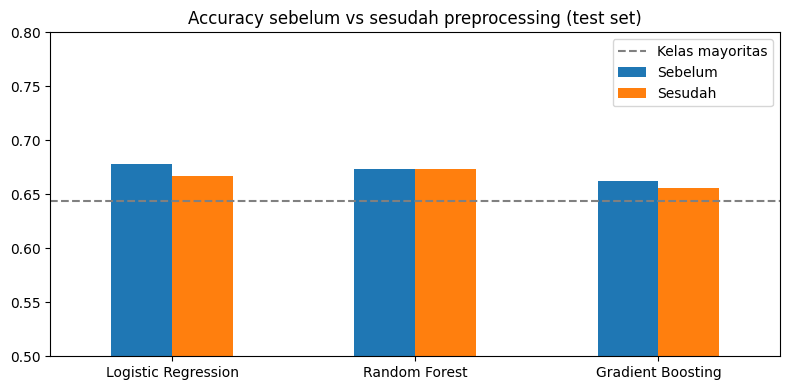

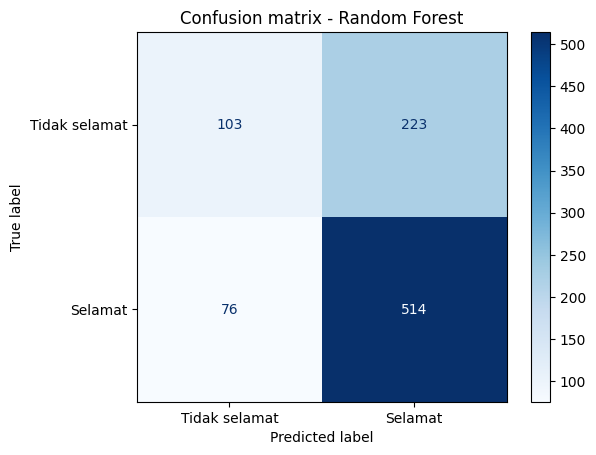

In [41]:
acc = pd.DataFrame({"Sebelum": {k: v["Accuracy"] for k, v in base_res.items()},
                    "Sesudah": {k: v["Accuracy"] for k, v in final_res.items()}})
acc["Selisih"] = (acc["Sesudah"] - acc["Sebelum"]).round(4)
print(acc.round(4))

acc[["Sebelum", "Sesudah"]].plot(kind="bar", figsize=(8, 4), ylim=(0.5, 0.8), rot=0)
plt.axhline(y_test.value_counts(normalize=True).max(), color="gray", linestyle="--", label="Kelas mayoritas")
plt.title("Accuracy sebelum vs sesudah preprocessing (test set)")
plt.legend(); plt.tight_layout(); plt.show()

best = pd.DataFrame(final_res).T["Accuracy"].idxmax()
ConfusionMatrixDisplay(confusion_matrix(y_te, final_pred[best]),
                       display_labels=["Tidak selamat", "Selamat"]).plot(cmap="Blues")
plt.title(f"Confusion matrix - {best}"); plt.show()

In [42]:
# Validasi lebih stabil: 5-fold CV pada seluruh data train (preprocessing di dalam pipeline)
rows = []
for name, mf in final_models.items():
    m0, s0 = cv_acc(lambda mf=mf: Pipeline([("imp", SimpleImputer(strategy="median")), ("model", mf())]), X_train, y_train)
    m1, s1 = cv_acc(lambda mf=mf: final_pipe(mf), X_train_n, y_train)   # aturan domain per-baris sudah diterapkan
    rows.append({"Model": name, "CV sebelum": f"{m0:.4f} +/- {s0:.4f}", "CV sesudah": f"{m1:.4f} +/- {s1:.4f}"})
    log_result("8. Final", f"Sebelum - {name}", m0, s0)
    log_result("8. Final", f"Sesudah - {name}", m1, s1)
pd.DataFrame(rows).set_index("Model")

,CV sebelum,CV sesudah
Model,,
Logistic Regression,0.6657 +/- 0.0104,0.6618 +/- 0.0106
Random Forest,0.6583 +/- 0.0079,0.6648 +/- 0.0133
Gradient Boosting,0.6526 +/- 0.0095,0.6509 +/- 0.0168


### Ringkasan seluruh eksperimen

In [43]:
summary = pd.DataFrame(EXPERIMENT_LOG)
summary

,Tahap,Variasi,CV accuracy,Std
0,5.3 Missing value,Listwise deletion,0.6611,0.0150
1,5.3 Missing value,Hapus kolom missing > 10%,0.6686,0.0178
2,5.3 Missing value,"Ignoring (HistGradientBoosting, NaN native)",0.6419,0.0182
3,5.3 Missing value,Imputasi konstanta 0,0.6667,0.0132
4,5.3 Missing value,Imputasi mean,0.6667,0.0132
...,...,...,...,...
68,8. Final,Sesudah - Logistic Regression,0.6618,0.0106
69,8. Final,Sebelum - Random Forest,0.6583,0.0079
70,8. Final,Sesudah - Random Forest,0.6648,0.0133
71,8. Final,Sebelum - Gradient Boosting,0.6526,0.0095


In [44]:
# (Opsional) Terapkan pipeline pada test.csv dan simpan prediksi probabilitas,
# format mengikuti sample_submission.csv (patient_id, survived_icu)
if os.path.exists("test.csv"):
    test_raw = pd.read_csv("test.csv", na_values=NA_VALUES)
    ids = test_raw["patient_id"]
    X_new = rule_based_clean(test_raw.drop(columns=["patient_id"]))

    X_all = rule_based_clean(X).loc[~X.duplicated(keep="first")]
    y_all = y.loc[X_all.index]
    model = final_pipe(lr_model).fit(X_all, y_all)

    submission = pd.DataFrame({"patient_id": ids, "survived_icu": model.predict_proba(X_new)[:, 1]})
    submission.to_csv("submission.csv", index=False)
    print(submission.head())

## 9. Kesimpulan

*(Sesuaikan angka dengan output yang kamu dapat saat menjalankan notebook; hasil bisa sedikit berbeda antar versi library.)*

**Temuan kualitas data.** Dataset mengandung noise (nilai fisiologis mustahil seperti heart rate > 1000), outlier ekstrem, tekanan darah tidak konsisten (346 baris diastolik >= sistolik), duplikat tersembunyi (58 baris selain ID), dan missing value berkelompok (575 baris dengan lima kolom kosong bersamaan) yang polanya konsisten dengan MCAR.

**Cakupan preprocessing.** Seluruh tahapan dari slide diterapkan: cleaning (noise, duplicate, missing, outlier), transformation (encoding, scaling, smoothing, aggregation, discretization, feature engineering), dan reduction (seleksi fitur, PCA). Setiap teknik diuji dengan model supervised dan dicatat di tabel ringkasan.

**Hasil.** Accuracy semua perlakuan berada di kisaran 0,65-0,67, hanya sedikit di atas tebakan kelas mayoritas (64%). Selisih antar teknik umumnya lebih kecil daripada simpangan baku antar fold (sekitar 0,01), sehingga tidak ada teknik yang terbukti lebih baik. Pipeline lengkap dibanding baseline data kotor juga tidak konsisten arahnya: Logistic Regression sedikit turun, Random Forest naik pada CV, Gradient Boosting hampir sama.

**Pengaruh yang terlihat jelas.** Hanya satu: scaling pada KNN (sekitar 0,62 tanpa scaling menjadi 0,63-0,64 dengan scaling), sesuai pesan slide bahwa model berbeda membutuhkan preprocessing berbeda. Selain itu, fitur interaksi `age_x_severity` memiliki korelasi terkuat dengan target di antara semua fitur.

**Penjelasan.** Kolom yang kotor (heart rate, tekanan darah, glucose, creatinine, WBC, BMI) hampir tidak berkorelasi dengan target, sedangkan sinyal prediktif ada pada kolom yang relatif bersih (age, severity_score, ventilation_required, chronic_conditions). Membersihkan noise membuat data valid, tetapi tidak menambah informasi yang memang tidak ada.

**Pelajaran.** *Garbage in, garbage out* berlaku dua arah: preprocessing tidak bisa menciptakan sinyal yang tidak ada di data. Nilai preprocessing di sini adalah validitas data dan pipeline yang bebas data leakage serta dapat dipakai ulang pada data baru.